# TechnoStamp - análisis integral


In [13]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "03_notebooks" else NOTEBOOK_DIR
SCRIPTS_DIR = PROJECT_ROOT / "04_scripts"
VISUALIZACIONES_DIR = PROJECT_ROOT / "06_resultados" / "Discovery" / "visualizaciones"

if not SCRIPTS_DIR.exists():
    raise FileNotFoundError(f"No se encontro la carpeta de scripts: {SCRIPTS_DIR}")

def _mostrar_salida(texto: str, stream) -> None:
    if texto:
        print(texto, end="" if texto.endswith("\n") else "\n", file=stream)

def mostrar_graficos(nombres: list[str], width: int = 1100) -> None:
    for nombre in nombres:
        imagen = VISUALIZACIONES_DIR / nombre
        if not imagen.exists():
            raise FileNotFoundError(f"No se encontro el grafico: {imagen}")
        display(Image(filename=str(imagen), width=width))


def ejecutar_etapa(nombre_script: str) -> None:
    script = SCRIPTS_DIR / nombre_script

    if not script.exists():
        raise FileNotFoundError(f"No existe el script: {script}")

    ejecutor = "\n".join([
        "import pandas as pd, runpy, sys",
        "pd.set_option('display.float_format', lambda x: format(x, ',.10f').rstrip('0').rstrip('.'))",
        "runpy.run_path(sys.argv[1], run_name='__main__')",
    ])
    resultado = subprocess.run(
        [sys.executable, "-c", ejecutor, str(script)],
        cwd=PROJECT_ROOT,
        text=True,
        encoding="utf-8",
        errors="strict",
        capture_output=True,
        check=False,
    )

    _mostrar_salida(resultado.stdout, sys.stdout)
    _mostrar_salida(resultado.stderr, sys.stderr)

    if resultado.returncode != 0:
        raise subprocess.CalledProcessError(
            resultado.returncode,
            resultado.args,
            output=resultado.stdout,
            stderr=resultado.stderr,
        )

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Scripts: {SCRIPTS_DIR}")


Proyecto: C:\Users\Dell\Agus\Nivii AI
Scripts: C:\Users\Dell\Agus\Nivii AI\04_scripts


## 1. Perfilado inicial

Datos generales del personal estan completos, pero las métricas de produccción tienen muchos nulos. Decidí no imputarlos automáticamente porque todos necesitan una explicacion relacionada al negocio. No se eliminaron filas ni modificaron valores extremos, nomas se marcaron para revisarlas bien.

**Script ejecutado:** `04_scripts/01_perfilado.py`
Los eventos de RR. HH. y las capacitaciones complementan la información sobre movimientos, incidentes y desarrollo del personal.

In [14]:
ejecutar_etapa("01_perfilado.py")


TABLA: empleados_mensual   shape=(9733, 47)
------------------------------------------------------------------------------------------
                                dtype  n_nulos  pct_nulos  n_unicos               ejemplo
empleado_id                     int64        0          0       694                  1000
mes_snapshot                      str        0          0        17            2024-01-01
activo                           bool        0          0         2                  True
nombre                            str        0          0       596         Teresa Carmen
genero                            str        0          0         2                     F
edad                            int64        0          0        41                    62
fecha_nacimiento                  str        0          0       127            1962-06-15
fecha_ingreso                     str        0          0       103            2012-01-01
antiguedad_meses                int64        0         

## 2. Calidad de datos

Tiene que leerse en UTF-8 para evitar caracteres raros.
Se detectaron inconsistencias en 51 edades, 483 antigüedades y 71 registros anteriores al ingreso. Se las marcó para revisarlas. Los salarios altos (numéricamente outliers) tienen coherencia con cargos mas altos, por eso no los elimino.
Se unificaron categorías como “Técnica/Técnico”, “Mixta/Mixto” y “high/Grave”;

**Script ejecutado:** `04_scripts/02_calidad.py`


In [15]:
ejecutar_etapa("02_calidad.py")


### 1. ENCODING
  utf-8      OK -> puesto ejemplo: 'Técnico Setup'
  latin-1    OK -> puesto ejemplo: 'TÃ©cnico Setup'
  cp1252     FALLA: UnicodeDecodeError

### 2. GRANULARIDAD empleados_mensual
  filas: 9733 | empleados unicos: 694 | meses: 17
  duplicados (empleado_id, mes_snapshot): 0
  rango meses: 2024-01-01 -> 2025-05-01

  headcount ACTIVO por mes:
              filas  activos
mes_snapshot                
2024-01-01      605      586
2024-02-01      587      587
2024-03-01      591      574
2024-04-01      577      568
2024-05-01      572      567
2024-06-01      571      564
2024-07-01      570      566
2024-08-01      572      562
2024-09-01      566      560
2024-10-01      565      562
2024-11-01      567      563
2024-12-01      566      552
2025-01-01      558      554
2025-02-01      560      553
2025-03-01      563      559
2025-04-01      577      562
2025-05-01      566      562

### 3. CONSISTENCIA INTERNA
  edad declarada vs calculada -> dif abs >1 anio: 51
  antig

## 3. Limpieza y preparación 

Normaliza nombres y tipos (acentos y eñes), documenta por qué faltan datos y marca inconsistencias sin borrar información. 
**Script ejecutado:** `04_scripts/13_limpieza_v2.py`


In [16]:
ejecutar_etapa("13_limpieza_v2.py")


Carga OK — empleados (9733, 47) | eventos (8705, 18) | capacitaciones (729, 17)

MEJORA 3 — nombres de columna sin eñes ni acentos
  [renombrar_columna] {'tabla': 'empleados', 'de': 'años_en_puesto_actual', 'a': 'anios_en_puesto_actual'}
  [renombrar_columna] {'tabla': 'empleados', 'de': 'horas_training_acumulado_año', 'a': 'horas_training_acumulado_anio'}
  Nombres finales verificados como unicos en las 3 tablas

MEJORA 4 — tipos correctos
  [a_fecha] {'tabla': 'empleados', 'col': 'mes_snapshot'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_nacimiento'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_ingreso'}
  [a_fecha] {'tabla': 'empleados', 'col': 'fecha_salida'}
  [a_fecha] {'tabla': 'empleados', 'col': 'ultimo_training_fecha'}
  [a_fecha] {'tabla': 'eventos', 'col': 'fecha_evento'}
  [a_fecha] {'tabla': 'capacitaciones', 'col': 'fecha_inicio'}
  [a_fecha] {'tabla': 'capacitaciones', 'col': 'fecha_fin'}
  [a_entero_con_vacios] {'tabla': 'empleados', 'col': 'manager_id', 'dec

## 4. P1 y P2 - sucesión y equidad

Calcula el riesgo de sucesión por puesto y describe la distribución de género por área y nivel. Ayuda a encontrar posiciones críticas y posibles brechas.

**Script ejecutado:** `04_scripts/04_p1_p2.py`


In [17]:
ejecutar_etapa("04_p1_p2.py")


Universo de analisis: 562 empleados ACTIVOS a 2025-05-01

P1 — RIESGO DE SUCESION / JUBILACION
Criterio activo de criticidad: indice propio (score_crit >= 2); es_posicion_critica se conserva solo para auditoria.

Jubilaciones proximas (sobre 562 activos):
  <= 12 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 24 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 36 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1
  <= 60 meses   :   4 empleados ( 0.7%) | de ellos criticos por indice: 1

Posiciones con criticidad estimada activa: 47 (8.4% de la dotacion)

--- Criticidad estimada que se jubila en <=12m, por area y puesto ---
                                   n  edad_prom  antig_anios  meses_rest              salario
area      puesto                                                                             
Logística Supervisor de Logística  1         64          4.3           6 3,486,692.6000000001

  TOTAL con criticidad es

C:\Users\Dell\Agus\Nivii AI\04_scripts\04_p1_p2.py:64: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  g["total"]=g.sum(1); g["pct_F"]=(g.get("F",0)/g.total*100).round(1)
C:\Users\Dell\Agus\Nivii AI\04_scripts\04_p1_p2.py:70: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  n["total"]=n.sum(1); n["pct_F"]=(n.get("F",0)/n.total*100).round(1)


## 5. Verificación de posiciones críticas

Contrasta dotación reducida, roles de liderazgo y antigüedad. Así no se llama crítico a un puesto por una sola señal aislada.

**Script ejecutado:** `04_scripts/05_verif_critica.py`


In [18]:
ejecutar_etapa("05_verif_critica.py")


### es_posicion_critica
  filas panel con critica=True: 152
  empleados que ALGUNA VEZ fueron criticos: 10
  empleados criticos en su ULTIMO snapshot: 10
  varia dentro del mismo empleado?: 0 empleados

  Quienes son los criticos (activos):
 empleado_id                    area                  puesto  nivel_jerarquico  edad  antiguedad_anios  span_of_control  meses_hasta_jubilacion
        1098               Estampado           Técnico Setup                 1    64              11.3                0                       6
        1484 Mantenimiento Eléctrico          Instrumentista                 1    58               6.4                0                      66
        1542               Logística   Team Leader Logística                 2    62               6.3                1                      12
        1544               Logística   Team Leader Logística                 2    63               4.3                2                       9
        1547               Logística Su

## 6. carga, seguridad y rotación

Genera indicadores de horas extra, sobrecarga, incidentes y rotación. Estos indicadores conectan bienestar operativo y riesgo de salida.

**Script ejecutado:** `04_scripts/06_p3_p4_p5.py`


In [19]:
ejecutar_etapa("06_p3_p4_p5.py")


P3 - HORAS EXTRA: CONCENTRACION Y COSTO

Costo TOTAL horas extra (17 meses): $1,399,111,105 | sobre nomina base: 8.3%
Costo HE anualizado (12m): $987,607,839

--- Pareto: concentracion del costo de HE por empleado ---
  Top    5% empleados ( 33 pers.) concentran 10.7% del costo de HE
  Top   10% empleados ( 67 pers.) concentran 19.5% del costo de HE
  Top   20% empleados (135 pers.) concentran 34.6% del costo de HE
  Top   30% empleados (202 pers.) concentran 47.6% del costo de HE

--- HE por AREA (promedio mensual por empleado) ---
                         emp  he_prom_mes  he_p90  pct_he_nomina               costo_he  costo_he_anual
area                                                                                                   
Mantenimiento Eléctrico   46        12.06   18.12          10.28  99,955,317.4300000072      70,556,695
Pintura                   80        11.92    16.5          10.16 204,050,231.7100000083     144,035,458
Logística                 35         11.5    

## 7. Verificación de incidentes y capacitación

Cruza información a nivel empleado-mes y compara fuentes. Es una auditoría para comprobar que los incidentes y la relación con capacitación son trazables.

**Script ejecutado:** `04_scripts/07_verif_incidentes_p5.py`


In [20]:
ejecutar_etapa("07_verif_incidentes_p5.py")


### DISCREPANCIA ENTRE FUENTES DE INCIDENTES
            eventos_rrhh  panel_count  dif
2024-01-01             3            3    0
2024-02-01             0            3    3
2024-03-01             4            5    1
2024-04-01             2            4    2
2024-05-01             3            5    2
2024-06-01             3            4    1
2024-07-01             2            6    4
2024-08-01             6            8    2
2024-09-01             5           10    5
2024-10-01             1            6    5
2024-11-01             3            6    3
2024-12-01             3            4    1
2025-01-01             1            5    4
2025-02-01             1            7    6
2025-03-01             3           10    7
2025-04-01             3            6    3
2025-05-01             2            8    6

  TOTAL eventos_rrhh: 45 | TOTAL panel (suma columna): 100
  Empleados-mes con count>1: 1 | max valor: 2
  Empleado-mes con evento registrado: 45
  Empleado-mes con count>0 en pane

C:\Users\Dell\Agus\Nivii AI\04_scripts\07_verif_incidentes_p5.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  cmp = pd.concat([a, b], axis=1).fillna(0).astype(int)


**Brecha prioritaria — N5, ficha de causa raíz.** De los 45 incidentes, 30 no tienen ninguna acción correctiva registrada y las 15 restantes repiten la misma frase. Sin este campo, ninguna conclusión de seguridad futura es defendible: es el dato que más desbloquea y el más barato de conseguir (control de proceso, no dato nuevo). Ver `03_insights_nuevos.md §3`.

## 8. Visualizaciones

Construye los gráficos de personas, equidad, carga, seguridad, rotación y trazabilidad a partir de los resultados de las etapas anteriores.

**Script ejecutado:** `04_scripts/08_visualizaciones.py`


  -> G1_piramide_etaria.png
  -> G2_genero_area_y_nivel.png
  -> G3_brecha_salarial.png
  -> G4_horas_extra.png
  -> G5_seguridad.png
  -> G6_antiguedad_rotacion.png
  -> G6_rotacion.png
  -> G7_brecha_trazabilidad.png
  -> G8_hora_extra_no_se_mueve.png
  -> G9_hora_extra_en_personas.png
  -> G15_costo_pieza_sube.png
  -> G16_rotacion_no_encarece.png

Listo. Visualizaciones en: C:\Users\Dell\Agus\Nivii AI\06_resultados\Discovery\visualizaciones


C:\Users\Dell\Agus\Nivii AI\04_scripts\08_visualizaciones.py:51: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  g["pct_F"] = (g.get("F", 0) / g.sum(1) * 100).round(1)
C:\Users\Dell\Agus\Nivii AI\04_scripts\08_visualizaciones.py:61: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  n["pct_F"] = (n.get("F", 0) / n.sum(1) * 100).round(1)


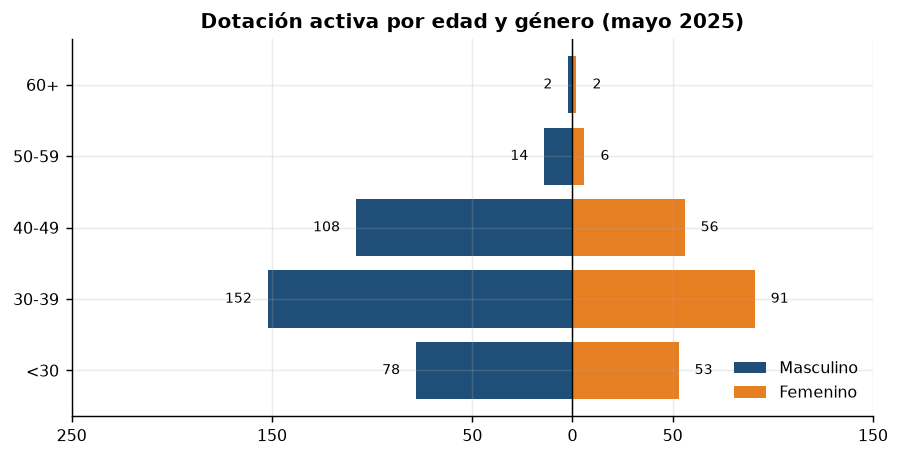

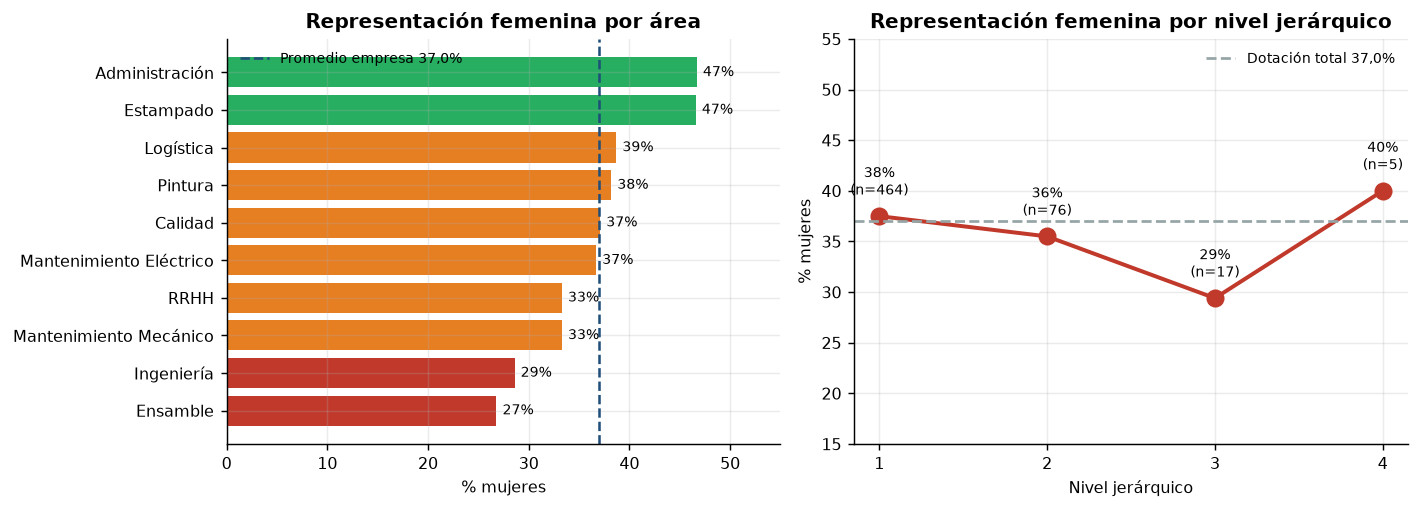

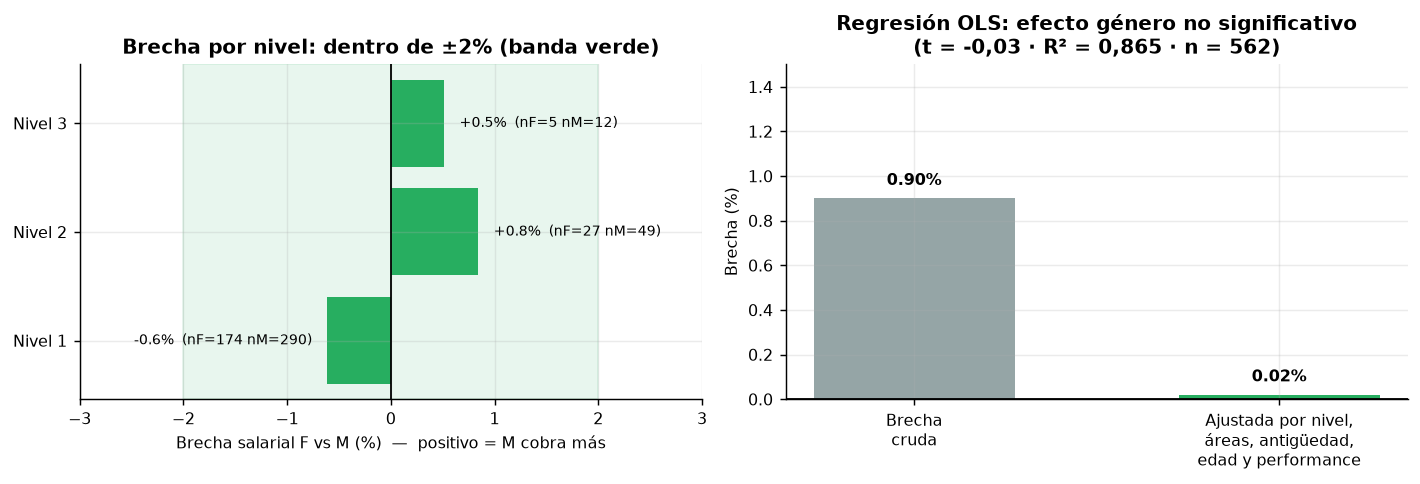

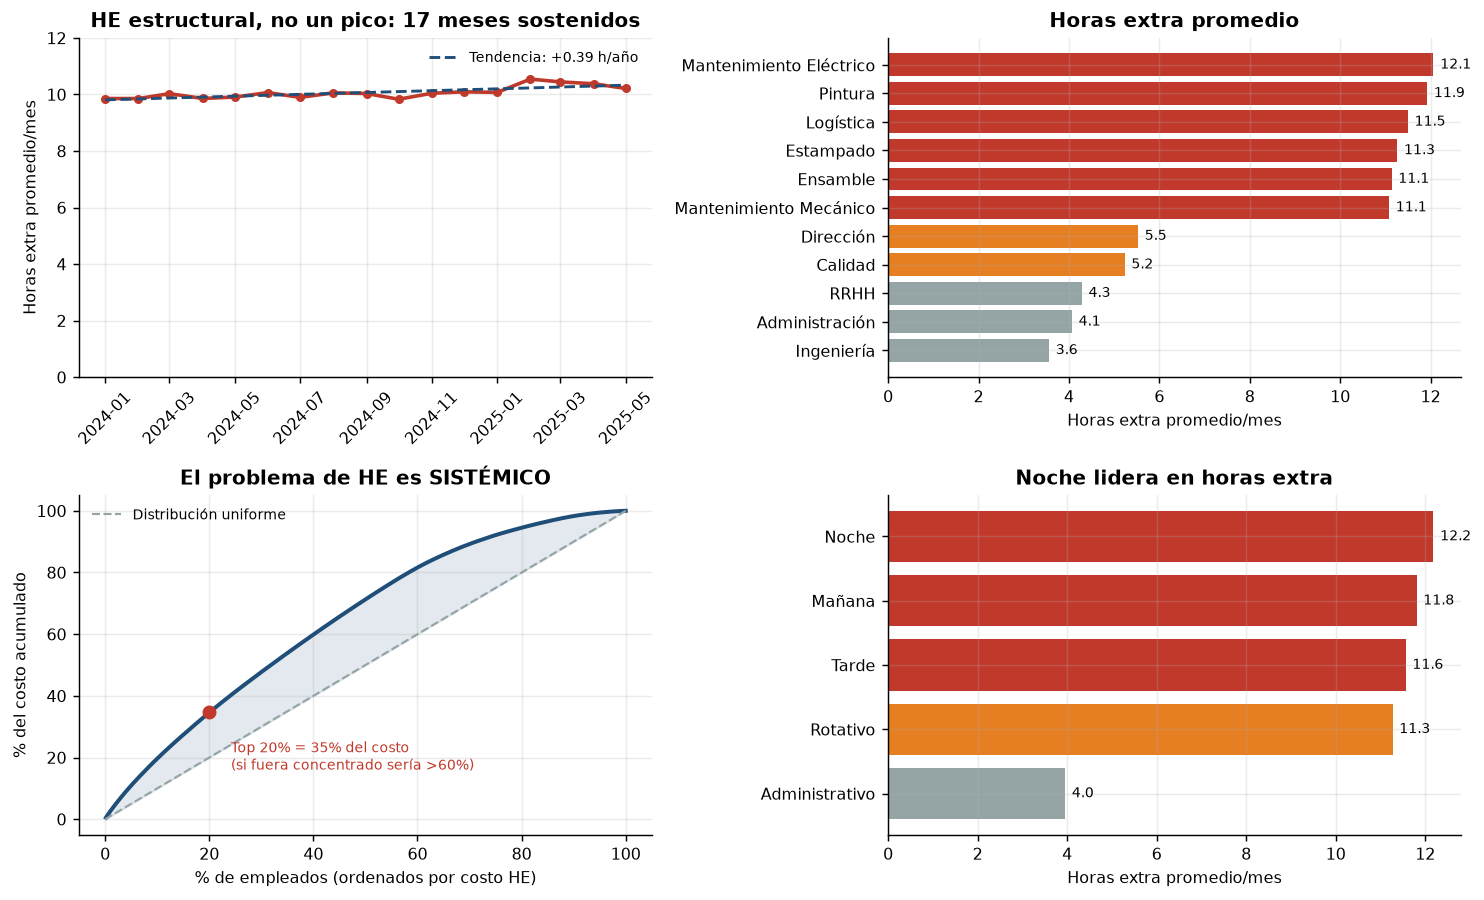

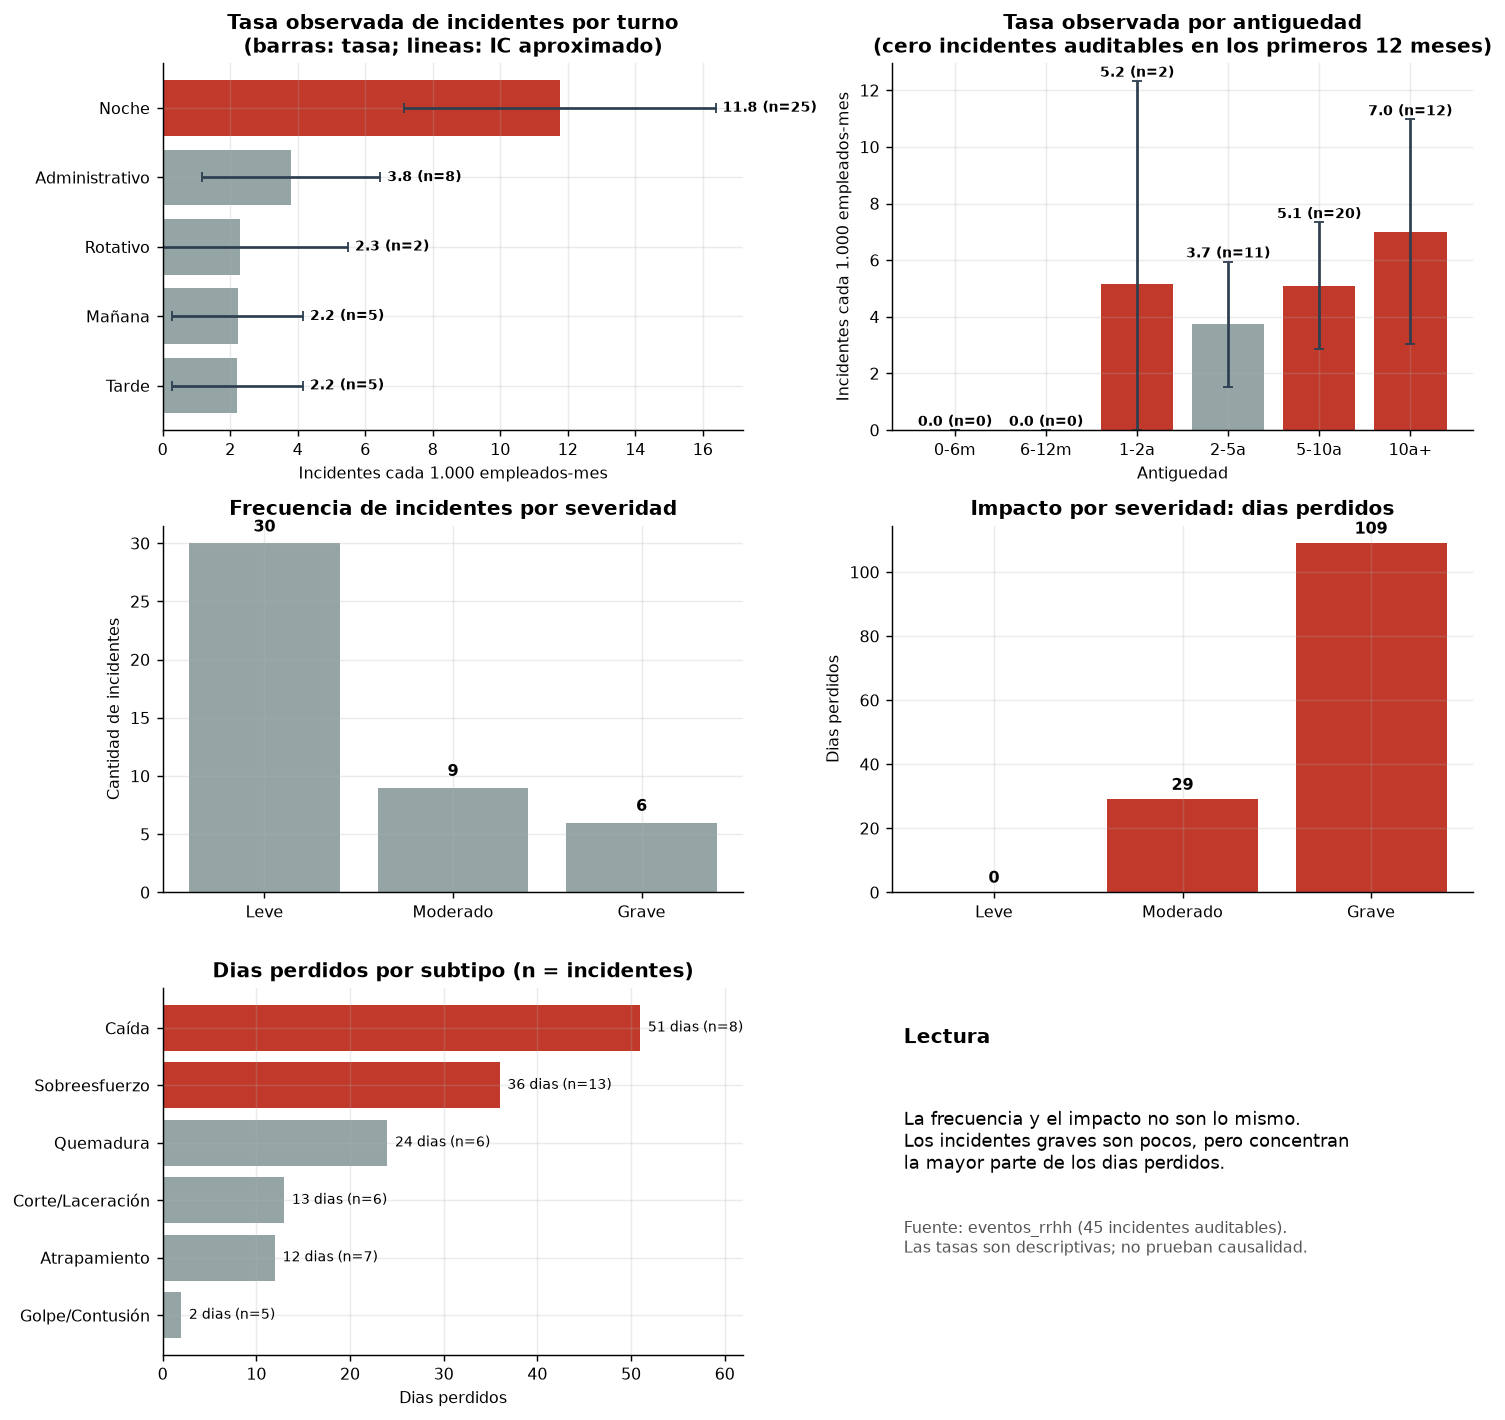

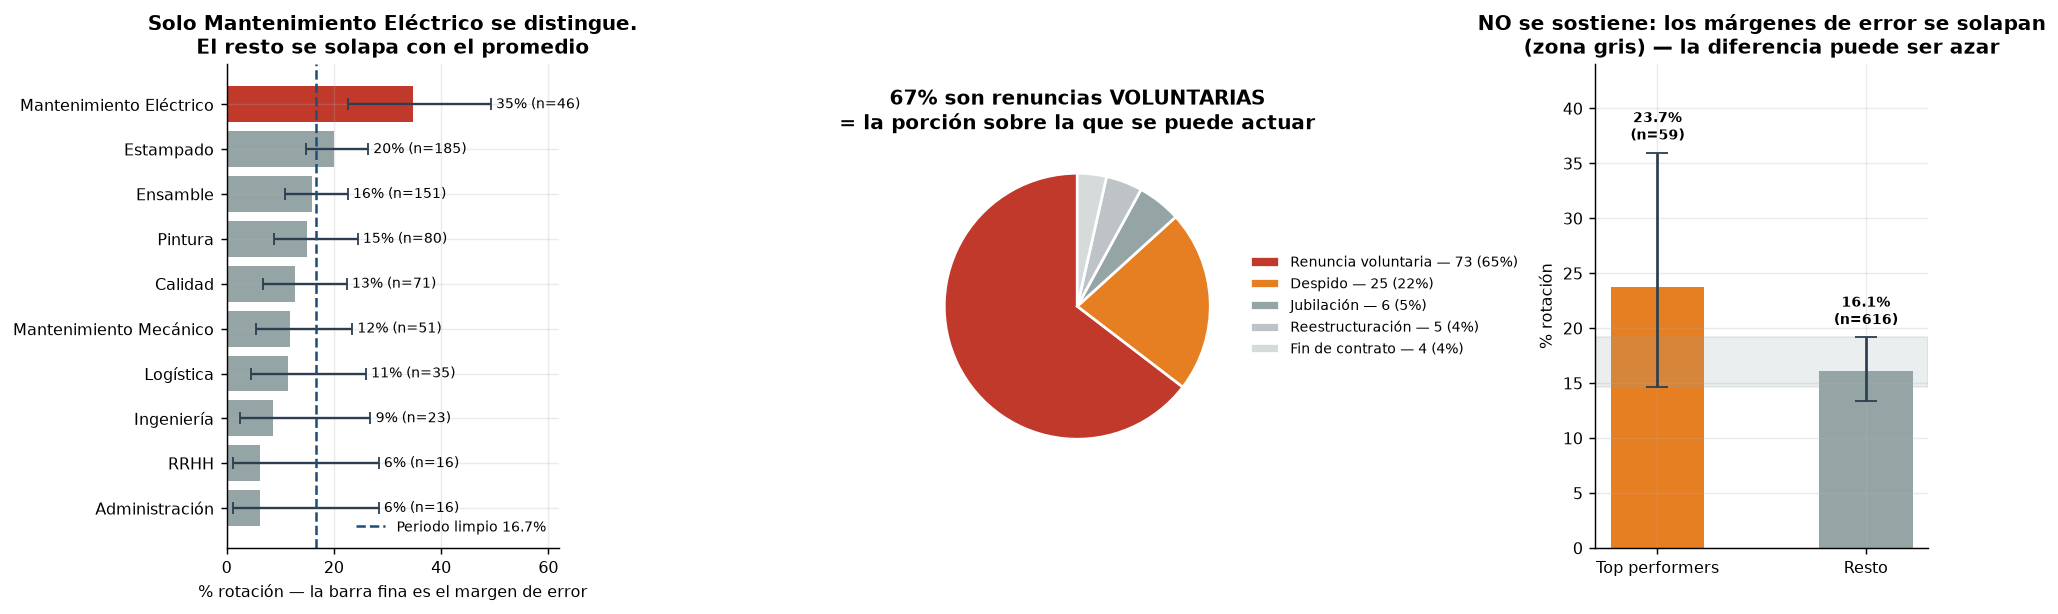

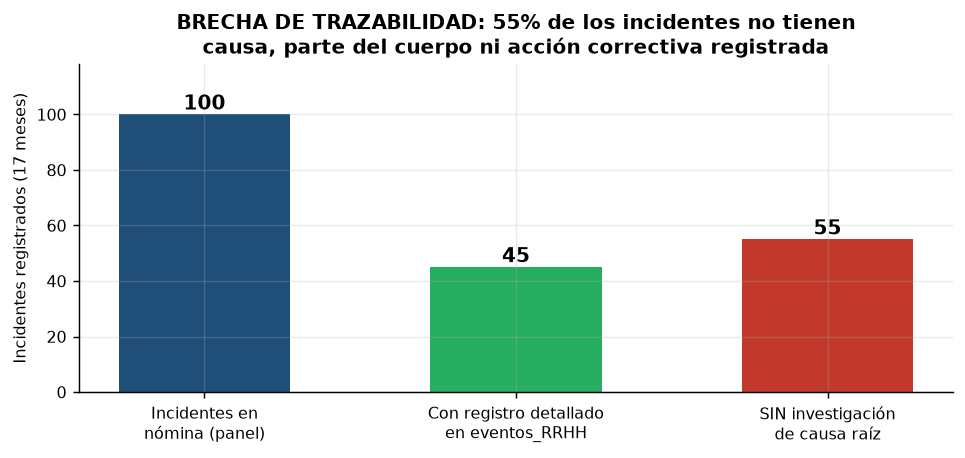

In [21]:
ejecutar_etapa("08_visualizaciones.py")
mostrar_graficos([
    "G1_piramide_etaria.png",
    "G2_genero_area_y_nivel.png",
    "G3_brecha_salarial.png",
    "G4_horas_extra.png",
    "G5_seguridad.png",
    "G6_rotacion.png",
    "G7_brecha_trazabilidad.png",
])


## 9. Sensibilidad de horas extra

Normaliza las ausencias por tiempo observado y prueba si la diferencia encontrada puede deberse al sesgo de exposición. Evita comparar empleados con distinta cantidad de meses registrados.

**Script ejecutado:** `04_scripts/10_sensibilidad_he.py`


In [22]:
ejecutar_etapa("10_sensibilidad_he.py")


### SENSIBILIDAD: cuando conviene contratar en vez de pagar horas extra?
  Recargo efectivo observado en los datos: 1.343x
  Regla: conviene contratar solo si (1 + cargas sociales) < recargo

  cargas   factor    veredicto
    15.0%   1.150    CONVIENE contratar
    25.0%   1.250    CONVIENE contratar
    30.0%   1.300    CONVIENE contratar
    33.8%   1.338    CONVIENE contratar
    40.0%   1.400    CONVIENE la hora extra
    45.0%   1.450    CONVIENE la hora extra
    50.0%   1.500    CONVIENE la hora extra

  --> PUNTO DE EQUILIBRIO: cargas sociales = 34.3%
  En Argentina las cargas patronales reales rondan 24-27% (Ley 27.541) mas ART,
  aguinaldo y vacaciones -> el costo cargado supera holgadamente el 34%.
  CONCLUSION: con estos datos, sustituir HE por dotacion NO genera ahorro.

### ENTONCES CUAL ES EL CASO REAL DE LAS HORAS EXTRA? -> fatiga y ausentismo

  Sobrecargados cronicos: 61 de 694 empleados (8.8%)
           n    he  meses_obs  ausencias_x_mes  lic_x_mes  rotacion  perf

## 10. Verificación de sobrecarga crónica y seguridad

¿Los empleados con horas extra crónicamente altas tienen más accidentes? --> No ,el test de diferencia de proporciones no es significativo. Se usa eventos_rrhh (fuente auditable)

Busca diferenciar una coincidencia casual de una relación que merece atención.

**Script ejecutado:** `04_scripts/11_verif_cronicos_seguridad.py`


In [23]:
ejecutar_etapa("11_verif_cronicos_seguridad.py")


### INCIDENTES DE SOBRECARGADOS CRONICOS — dos fuentes comparadas

  FUENTE A — panel (columna incidentes_seguridad_count):
         emp_meses  inc  tasa_x1000
cronico                            
False         8725   72         8.3
True           876   27        30.8
    ratio cronico/no-cronico: 3.71x

  FUENTE B — eventos_rrhh (auditable, con causa raiz):
         emp_meses  inc  tasa_x1000
cronico                            
False         8725   43         4.9
True           876    2         2.3
    ratio cronico/no-cronico: 0.47x

  Test de proporciones (fuente auditable): z = -1.09  -> NO significativo (p > 0.05)
  n incidentes en cronicos: 2 sobre 876 empleado-mes

### VEREDICTO
  Las fuentes DISCREPAN. El 3,7x del panel no se sostiene con la fuente auditable.
  Con n tan chico no se puede afirmar que la sobrecarga cronica cause accidentes.
  Nivel de evidencia: EXPLORATORIO. Requiere validacion antes de justificar inversion.


## 10b. Hora extra: estructural vs demanda

¿La hora extra de planta es dotación corta permanente o volatilidad de demanda? --> dotación corta permanente
La HE por persona es plana los 17 meses (CV 1–5%) y su varianza no está explicada por el volumen de producción (R² ≈ 0).  Equivale a entre 24 y 34 personas de producción faltantes, sostenido durante 17 meses. Insumo para el business case (§15).


**Script ejecutado:** `04_scripts/19_hora_extra_estructural.py`

In [24]:
ejecutar_etapa("19_hora_extra_estructural.py")

HORA EXTRA: ESTRUCTURAL vs DEMANDA   |   meses: 2024-01-01 -> 2025-05-01

### 0. Que contiene `horas_trabajadas`? (define el denominador de la mejora 2)
  turno teorico (duracion_turno x 21 dias) mediana :  168.0 h/mes
  horas_trabajadas mediana                          :  165.0 h/mes
  horas_extra mediana                               :   10.4 h/mes
  correlacion intra-persona horas_trabajadas ~ horas_extra: mediana 0.03 | 24% de las personas > 0.3
  -> HE aditiva (corr ~ 0). Base estandar = horas_trabajadas tal cual (~165 h/mes, coherente con el turno teorico de 168).

### 1. Nivel y planitud de la hora extra por area (dotacion activa)
                   area  headcount  he_emp_prom  he_min  he_max   CV  R2_vs_volumen    patron_aprox  costo_he_anual_MM
Mantenimiento Eléctrico         32         12.1    10.3    18.8 0.22           0.21      intermedio               70.6
                Pintura         72         11.9    11.4    12.4 0.03           0.06           plano                1

## 10c. Costo laboral por pieza buena (pregunta Q1)

1. Una pieza buena cuesta hoy ~$1,986 de mano de obra
     (Estampado $2,075, Ensamble $1,938, Pintura $1,944).
2. Ese costo subio ~17% en los 17 meses. Aprox. la mitad es menos piezas por hora
     trabajada (misma dotacion, menos produccion -> hora extra estructural, DEC-030); la otra
     mitad, el precio de la hora subiendo.
3. Palanca de gestion: el costo unitario baja recuperando volumen o ajustando la dotacion a
     la carga real, no tocando el scrap (2,3 %, chico) ni pidiendo mas horas extra.
4. La rotacion NO explica la variacion mes a mes del costo por pieza una vez descontada la
     tendencia (rot_pct t=-0.55). No hay caso para "retener para bajar el costo unitario"
     con esta evidencia.
5. Para medir el efecto real de una salida haria falta el costo de rampa (N1/N2), granularidad
     por linea/turno y costos deflactados. Hoy solo se sostiene lo descriptivo..

**Script ejecutado:** `04_scripts/20_costo_pieza_buena.py`  ·  **Gráficos:** `G15_costo_pieza_sube.png`, `G16_rotacion_no_encarece.png`

PASO 1 - PIEZAS BUENAS POR AREA-MES
           unid_mes  scrap_pct  buenas_mes  perdidas_scrap_mes  pct_en_scrap
area                                                                        
Ensamble  123,195.5        1.9   120,819.2               2,376          1.93
Estampado 143,054.9        2.6   139,365.2               3,690          2.58
Pintura    70,689.6        2.3    69,078.6               1,611          2.28

  Total: 5,727,981 producidas, 5,597,471 buenas (2.28% scrap, 130,510 piezas perdidas en 17 meses).

PASO 2 - COSTO LABORAL POR AREA-MES (salario + costo hora extra)
           costo_gente_mes  costo_sal_mes  costo_he_mes  hc  pct_he  costo_x_persona
area                                                                                
Ensamble       234,096,171    214,531,209    19,564,963 126     8.4        1,857,906
Estampado      288,743,800    264,498,135    24,245,664 146     8.4        1,977,697
Pintura        134,063,287    122,060,332    12,002,955  72       9     

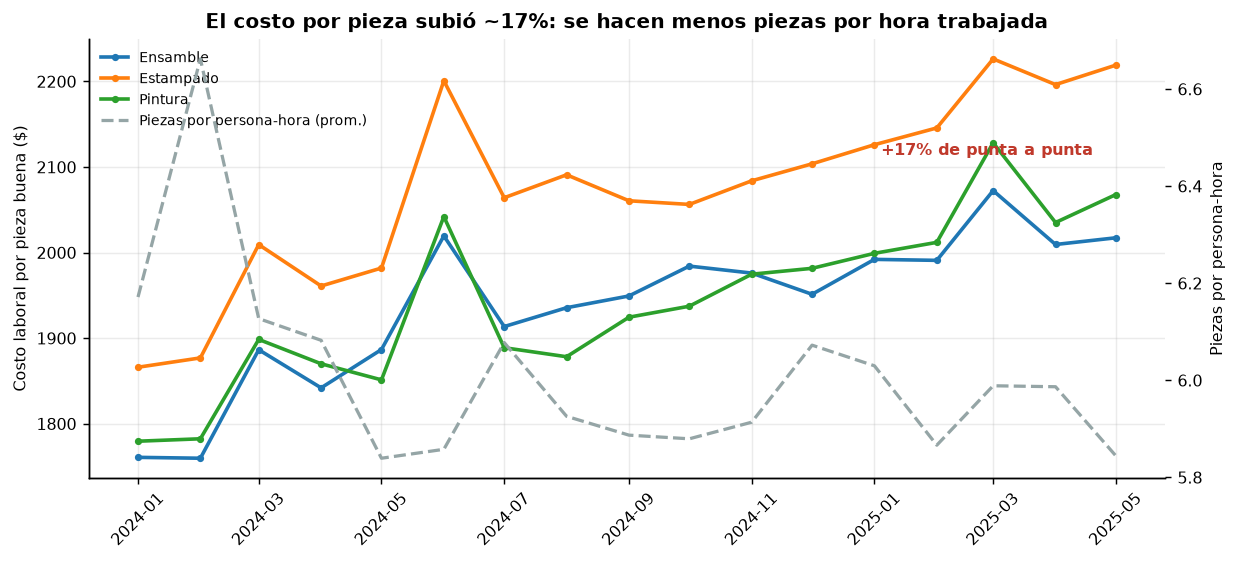

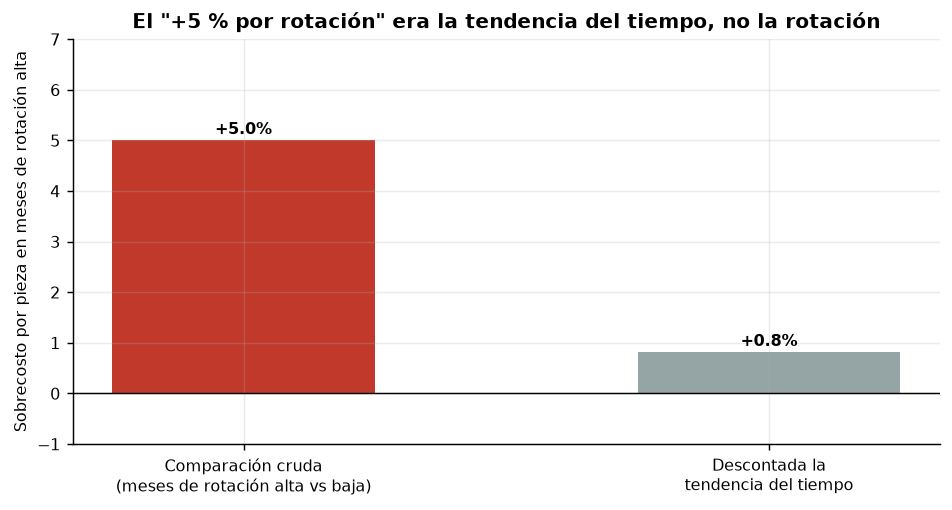

In [25]:
ejecutar_etapa("20_costo_pieza_buena.py")
mostrar_graficos(["G15_costo_pieza_sube.png", "G16_rotacion_no_encarece.png"])

## 11. Diagnóstico de gaps

Identifica limitaciones del dataset y separa datos medidos de supuestos. Marca qué conclusiones son sólidas y cuáles requieren validación con el cliente.

**Script ejecutado:** `04_scripts/12_diagnostico_gaps.py`


In [26]:
ejecutar_etapa("12_diagnostico_gaps.py")


GAP 1 — FALTANTES NO ALEATORIOS: mis comparaciones de scrap son validas?

  % nulos de tasa_scrap_porcentaje por categoria de collar:
                     n  pct_nulo
categoria_collar                
Blue             7,967      25.5
White            1,766      99.4

  % nulos por area:
                            n  pct_nulo
area                                   
Administración            259       100
Calidad                   976       100
Logística                 553       100
RRHH                      263       100
Ingeniería                373       100
Mantenimiento Mecánico    806       100
Mantenimiento Eléctrico   554       100
Dirección                  12       8.3
Estampado               2,531       0.2
Ensamble                2,173         0
Pintura                 1,233         0

  >> En el informe compare scrap accidentados (3,23) vs no accidentados (2,35).
            n  n_con_scrap  pct_perdido  scrap
tuvo_inc                                      
False     625     

## 12. EDA sistemático

Recorre las variables para detectar vacíos, rarezas, asimetrías y columnas poco informativas.
- accion_correctiva está casi siempre vacía y, cuando aparece, repite la misma respuesta.

- variables con cola larga deben analizarse con mediana o transformaciones, no solo con promedio.

- identificadores y nombres con alta cardinalidad: sirven para identificar, no para agrupar.

- Muchos faltantes son estructurales, no errores.
**Script ejecutado:** `04_scripts/14_eda_sistematico.py`


In [27]:
ejecutar_etapa("14_eda_sistematico.py")



TABLA empleados_mensual — 9,733 filas × 60 columnas
  numerica continua: 23 | booleana: 11 | categorica: 8 | numerica discreta: 8 | fecha: 5 | alta cardinalidad: 5

  32 alertas:
                      columna              tipo            alerta                     detalle
                       nombre alta cardinalidad ALTA CARDINALIDAD       596 valores distintos
                 fecha_salida             fecha            VACÍOS              98.6% sin dato
                motivo_salida        categorica            VACÍOS              98.6% sin dato
                         area        categorica   ETIQUETAS RARAS      1 etiquetas bajo el 1%
                      subarea        categorica   ETIQUETAS RARAS      6 etiquetas bajo el 1%
                       puesto alta cardinalidad ALTA CARDINALIDAD        52 valores distintos
             nivel_jerarquico numerica discreta    MUY ASIMÉTRICA  asimetría 2.8 — cola larga
               manager_nombre alta cardinalidad ALTA CARDINALIDAD   

## 13. Diagnóstico de fragilidad

El costo viejo por salida era frágil: 97% de los $5,88M provenían de supuestos de costos, no de datos observados. Un business case con más supuestos que datos tiene que publicarse como rango, no como cifra única.

Las 483 filas con antigüedad inconsistente afectan a 434 personas, pero no muestran reingresos, huecos históricos ni antigüedad decreciente. La rotación no está inflada.

La rotación del area "Mantenimiento Eléctrico" es la única que se distingue del promedio.

**Script ejecutado:** `04_scripts/15_diagnostico_fragilidad.py`


In [28]:
ejecutar_etapa("15_diagnostico_fragilidad.py")


A — DE QUE ESTA HECHO EL COSTO POR SALIDA ($5,88M)
  Reclutamiento (dato real del cliente)      $      150,000     2.6%
  Onboarding (dato real del cliente)         $       50,000     0.9%
  Vacancia (SUPUESTO NUESTRO)                $    2,908,893    49.5%
  Rampa 3 meses al 50% (SUPUESTO NUESTRO)    $    2,773,309    47.1%
  TOTAL                                      $    5,882,203

  >> 97% del costo por salida son supuestos nuestros, no datos del cliente.
  >> El business case de $92M descansa entero sobre eso.

  Sensibilidad — que pasa si los supuestos son mas conservadores:
    Solo datos reales (sin vacancia ni rampa)    $     200,000/salida -> ahorro 25% = $    3,141,176/anio
    Vacancia al 50%, rampa 2 meses al 30%        $   2,763,770/salida -> ahorro 25% = $   43,407,453/anio
    Nuestro escenario actual                     $   5,882,203/salida -> ahorro 25% = $   92,385,184/anio
    Vacancia completa, rampa 6 meses al 50%      $   8,655,512/salida -> ahorro 25% = $  135,9

C:\Users\Dell\Agus\Nivii AI\04_scripts\15_diagnostico_fragilidad.py:107: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  t = pd.concat([por_mes, hc], axis=1).dropna()


## 14. Rotación temporal 
No incluyo Enero 2024 en el periodo para medir la rotación, porque tiene 19 salidas, cuando un mes normal tiene aproximadamente 6. las 19 personas aparecen solo una vez; cuando el resto de las personas que salieron aparece, en promedio, 9,5 meses. Eso se llama "arrastre de corte". La rotación no tiene tendencia, no hay evidencia que esté aumentando ni disminuyendo.

Tomando desde febrero 2024, tasa oficial= 113 salidas / 675 personas = 16,7%

**Script ejecutado:** `04_scripts/16_rotacion_temporal.py`


In [27]:
ejecutar_etapa("16_rotacion_temporal.py")


DIAGNOSTICO — que pasa en enero 2024
  Salidas en 2024-01-01: 19  (un mes normal tiene ~6)
  Antiguedad media al salir: 5.2 anios
  Motivos: {'Renuncia voluntaria': np.int64(16), 'Despido': np.int64(2), 'Jubilación': np.int64(1)}

  Cuantos meses aparece cada uno en el panel antes de irse:
    {1: np.int64(19)}

  Comparado con el resto de las salidas:
    enero 2024: 1.0 meses observados en promedio
    resto     : 9.5 meses observados en promedio

  >> Salidas de enero-2024 que aparecen 1 solo mes: 19 de 19
     Son personas que ya estaban saliendo cuando empieza el archivo.
     No son rotacion generada en el periodo: son arrastre del corte.

RECALCULO — periodo limpio (desde febrero 2024)
  Todo el periodo (con enero 2024)     132 salidas / 694 personas expuestas ->  19.0% acumulado
  Periodo limpio (desde feb 2024)      113 salidas / 675 personas expuestas ->  16.7% acumulado

  >> La tasa acumulada con el arrastre incluido: 19.0%.
  >> Tasa corregida (definicion oficial, DEC-019)

**Antes de lanzar las entrevistas de salida (N3) y de ampliar la capacitación de seguridad (I8), definir la calidad del proceso, no solo si se ejecutó:**

- ¿Se hace el mismo día de la baja o semanas después? (sesgo de recuerdo)
- ¿La hace RR.HH. o el propio jefe? (sesga la respuesta)
- ¿El motivo queda en categorías cerradas y comparables entre bajas, o en texto libre no codificable?
- Para capacitación: ¿el criterio de asignación queda registrado? (I8 ya lo exige — sin esto nunca se podrá evaluar el efecto)

Sin esto, cualquiera de los dos procesos corre el riesgo de terminar como `meses_desde_ultimo_aumento`: un dato que se completa, pero que no mide lo que dice medir (DEC-023).

## 15. Business case 

Presenta el impacto con 3 escenarios posibles y separa datos reales (reclutamiento, onboarding, salario promedio y 47 días para cubrir el puesto) de supuestos (cuánto valor se pierde durante la vacancia y cuánto tarda el nuevo empleado en alcanzar productividad normal). También usa márgenes de error para tratar las diferencias entre áreas. 

Hay una señal descriptiva de que los "Top Performers" tienen mayor rotación, pero z = 1.51, por lo que la diferencia no se distingue estadísticamente. Puede ser azar o efecto de la muestra pequeña (n=8).

El costo real por salida termina dependiendo de cuánto de ese trabajo puede absorber el equipo y de la velocidad con que rinde el reemplazo.

Con 55 renuncias voluntarias anualizadas, el valor potencial de reducirlas queda entre: $23,3 millones y $194,8 millones por año. Para achicar ese rango, neceitaos datos de 
1. Producción mensual de un operario ya formado.
2. Meses que tarda un ingresante en alcanzar ese nivel.

**Script ejecutado:** `04_scripts/17_business_case_v2.py`


In [28]:
ejecutar_etapa("17_business_case_v2.py")


MEJORA 1 — COSTO POR SALIDA: DATO DURO vs SUPUESTO

  DATO DURO (registrado por el cliente)
    Reclutamiento              $     150,000
    Onboarding                 $      50,000
    Subtotal verificable       $     200,000

  SUPUESTOS (nuestros — el cliente no los mide)
    Salario medio del que sale $   1,901,634/mes   <- dato duro
    Dias para cubrir el puesto            47 dias  <- dato duro
    Fraccion del sueldo que se pierde durante la vacancia  <- SUPUESTO
    Meses de rampa y a que rendimiento                     <- SUPUESTO

  COSTO POR SALIDA SEGUN ESCENARIO
    conservador  $   2,836,933   (duro $200,000 + vacancia $1,495,952 + rampa $1,140,981)
                 el equipo absorbe parte del trabajo; el ingresante rinde 70% desde el mes 1
    central      $   6,044,356   (duro $200,000 + vacancia $2,991,905 + rampa $2,852,451)
                 el puesto queda descubierto; el ingresante rinde 50% durante 3 meses
    agresivo     $   8,896,808   (duro $200,000 + vacancia 

**Falta el costo del programa, no solo el ahorro.** El rango de $23,3M–$194,8M (`BC_supuestos.json`) es beneficio bruto evitado por reducir renuncias voluntarias — en ningún lugar se descuenta el costo del programa que generaría esa reducción (aumentos, mentoría, lo que se decida). El umbral real es: el programa vale la pena si su costo es menor al beneficio esperado. Contra el piso verificable de $1,64M/año —el único que no depende de supuestos propios— cualquier programa que cueste más ya es frágil sin más evidencia.

## 16. Visualizaciones para decision

Estos siete graficos conectan la evidencia con decisiones de rotacion, seguridad, sucesion, sobrecarga y business case. Se muestran  y tambien se guardan como archivos PNG.

**Script ejecutado:** `04_scripts/18_visualizaciones_decision.py`


  -> G8_rotacion_original_vs_limpia.png
  -> G9_rotacion_area_ic95.png
  -> G10_distribucion_horas_extra_area.png
  -> G11_incidentes_por_turno.png
  -> G12_capacitacion_seguridad_vs_incidentes.png
  -> G13_riesgo_sucesion_por_puesto.png
  -> G14_business_case_escenarios.png
Listo. Visualizaciones de decision en: C:\Users\Dell\Agus\Nivii AI\06_resultados\Discovery\visualizaciones


C:\Users\Dell\Agus\Nivii AI\04_scripts\18_visualizaciones_decision.py:76: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(datos, tick_labels=orden, vert=False, patch_artist=True, showfliers=False)


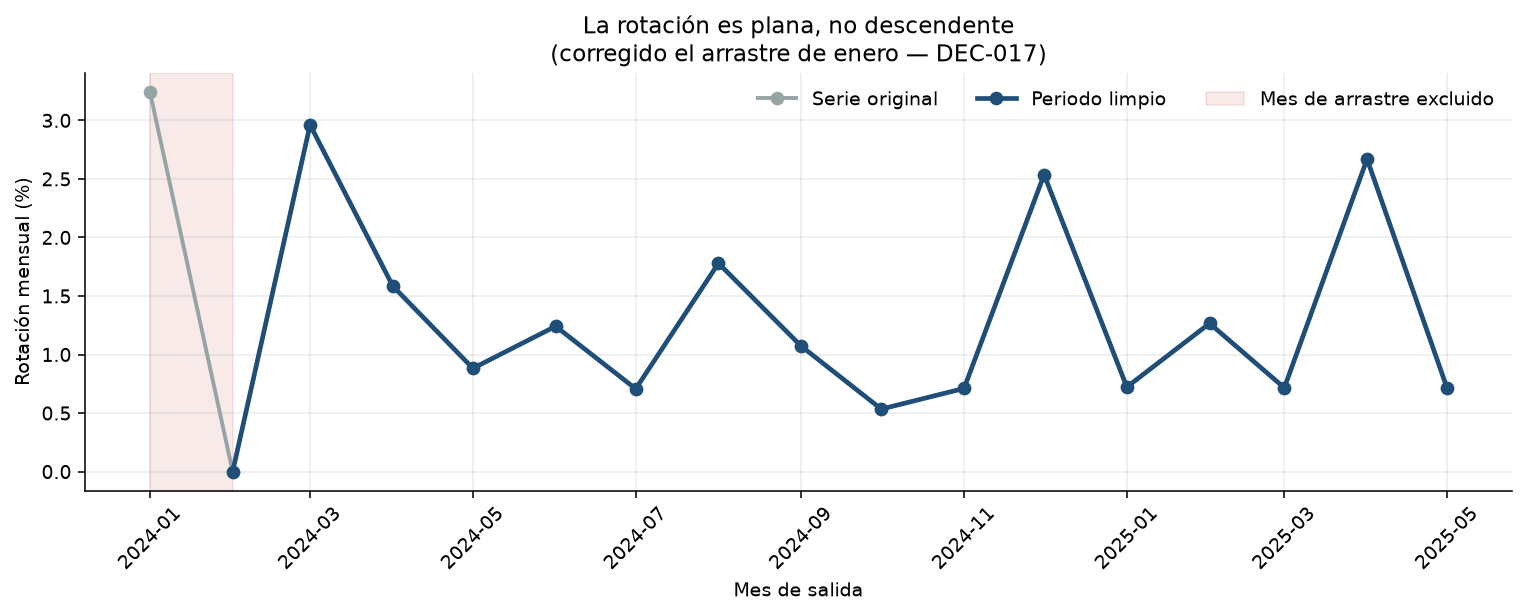

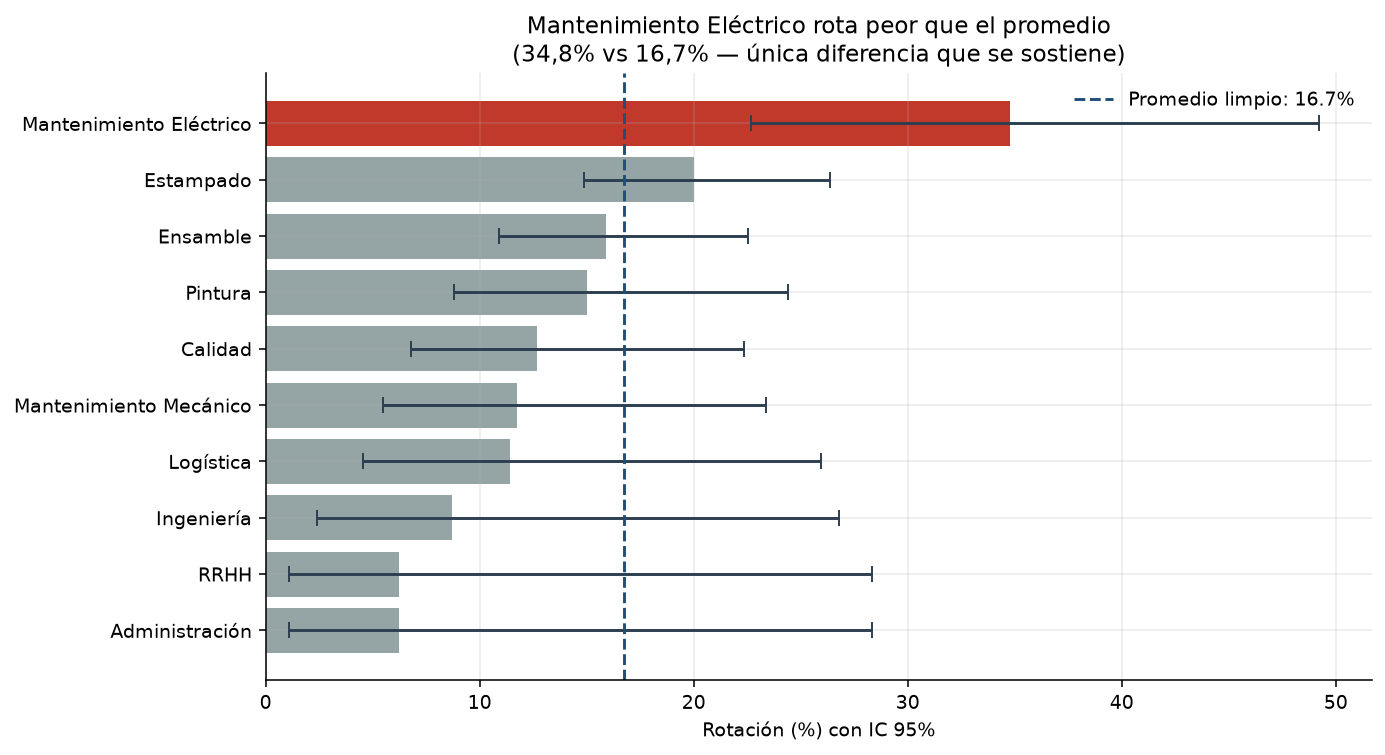

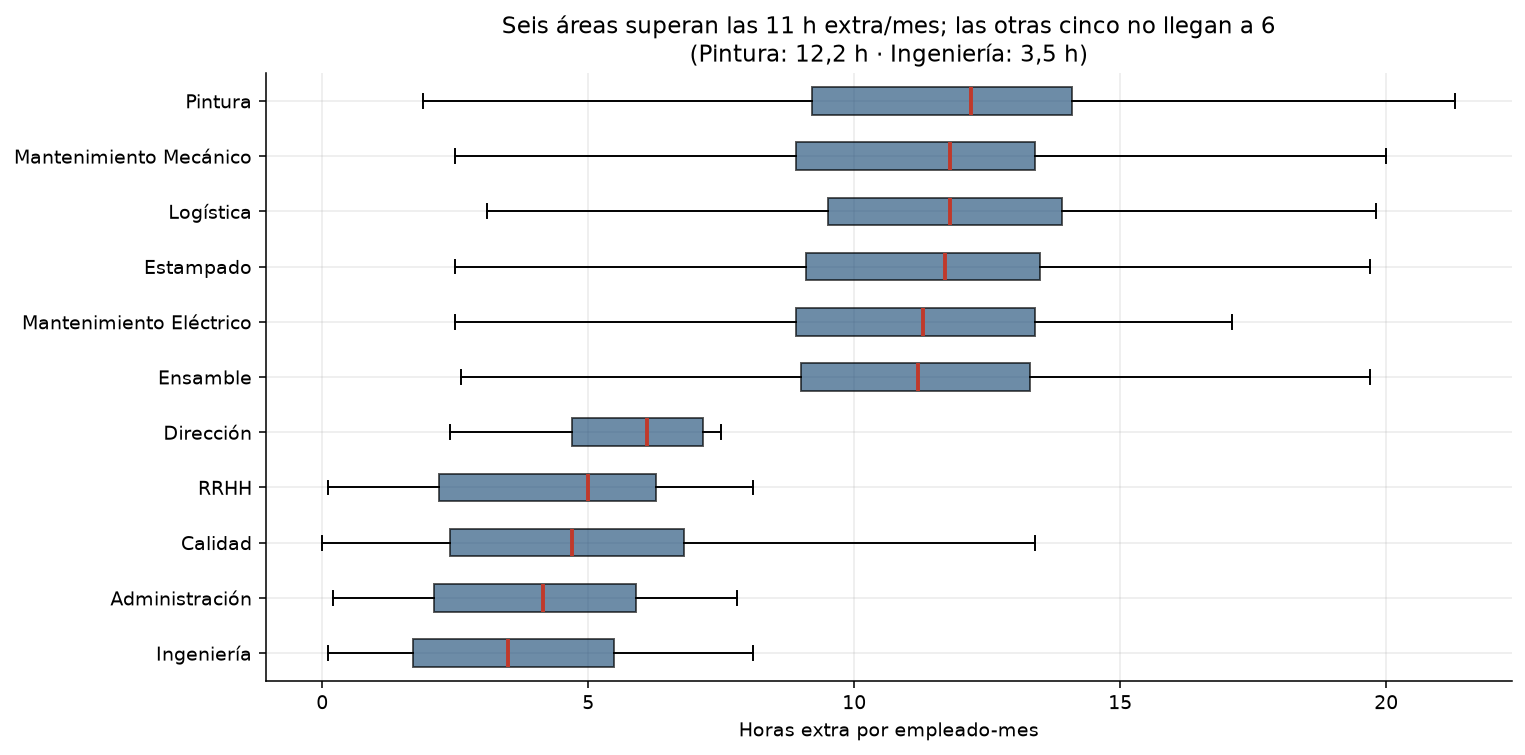

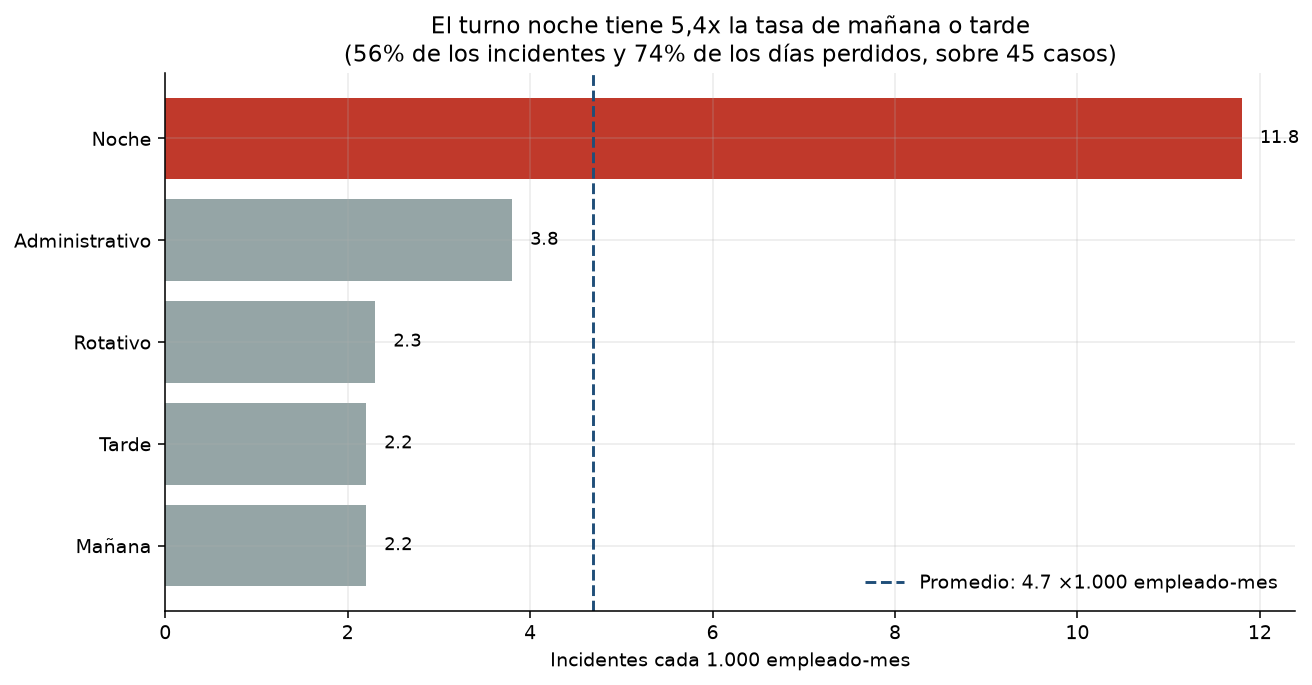

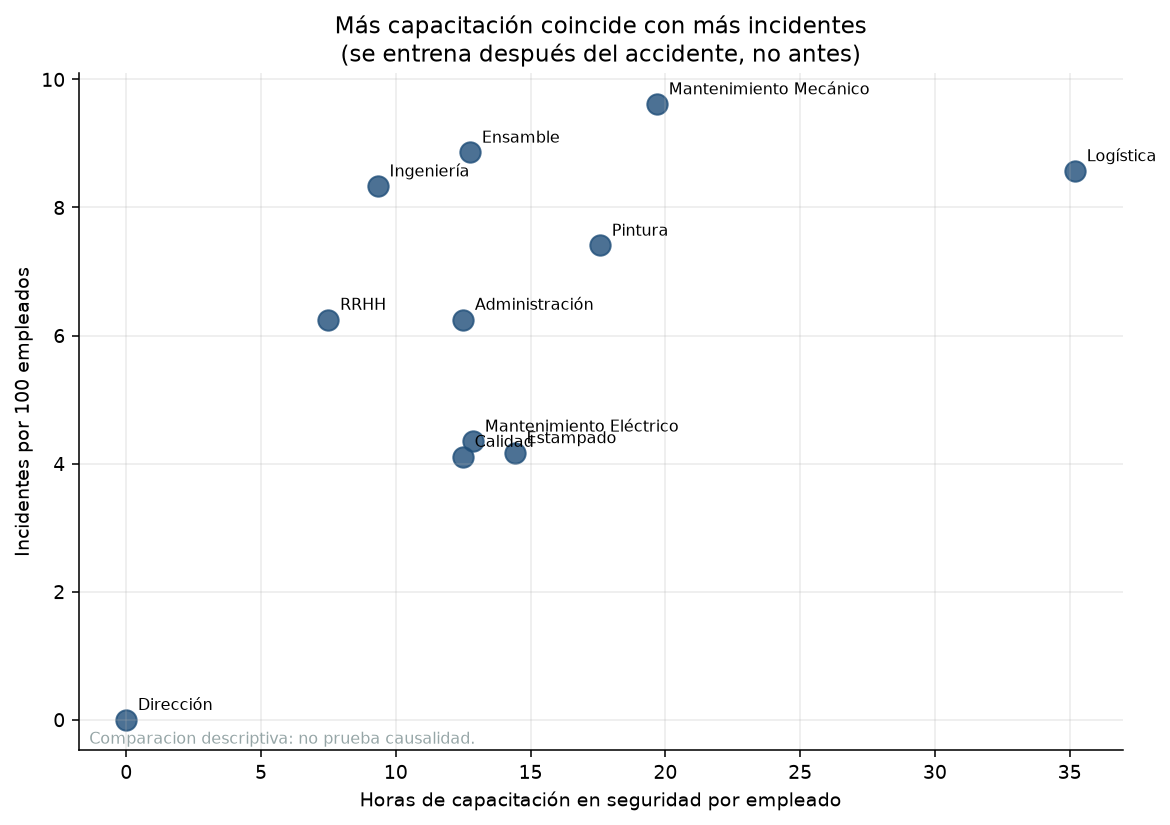

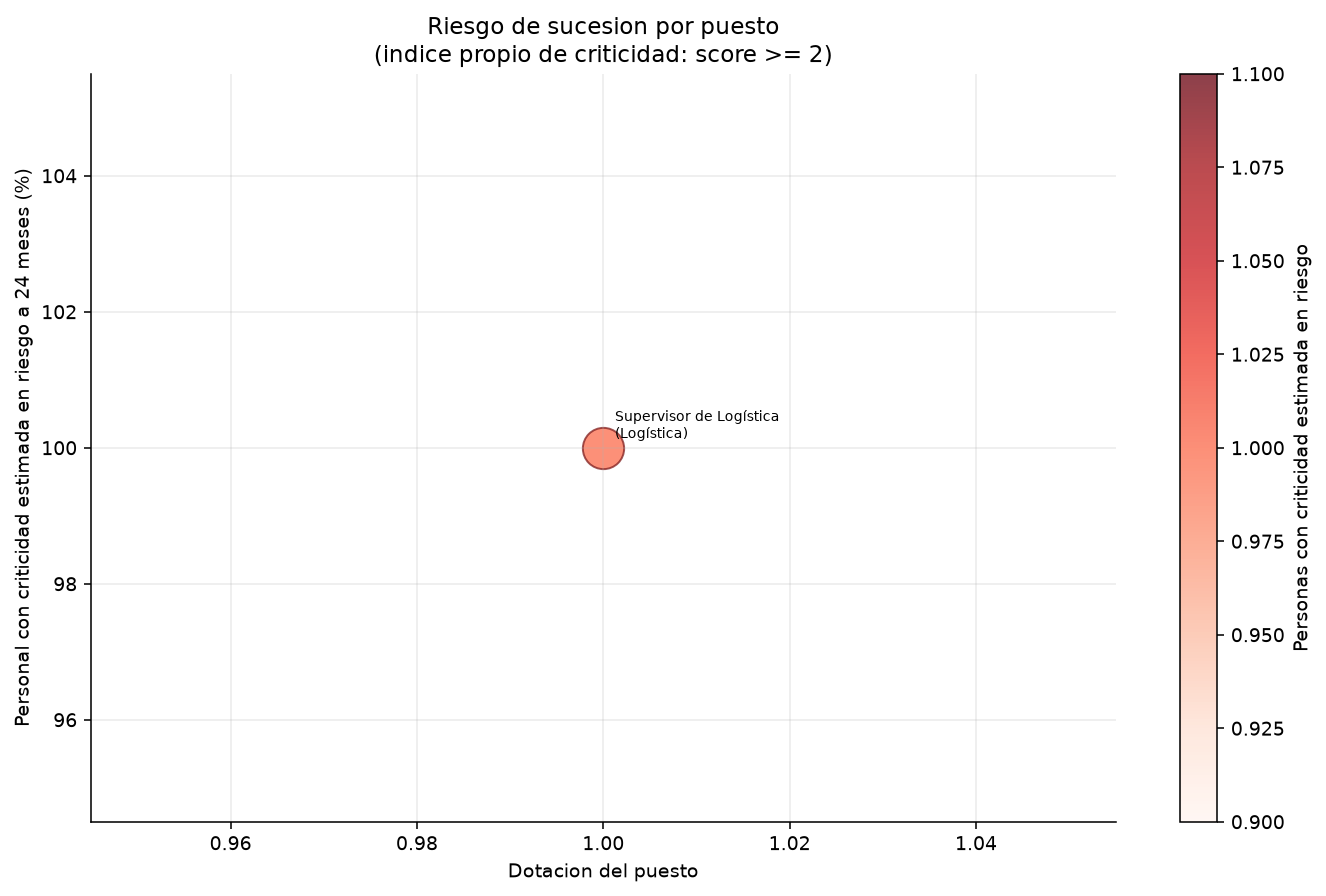

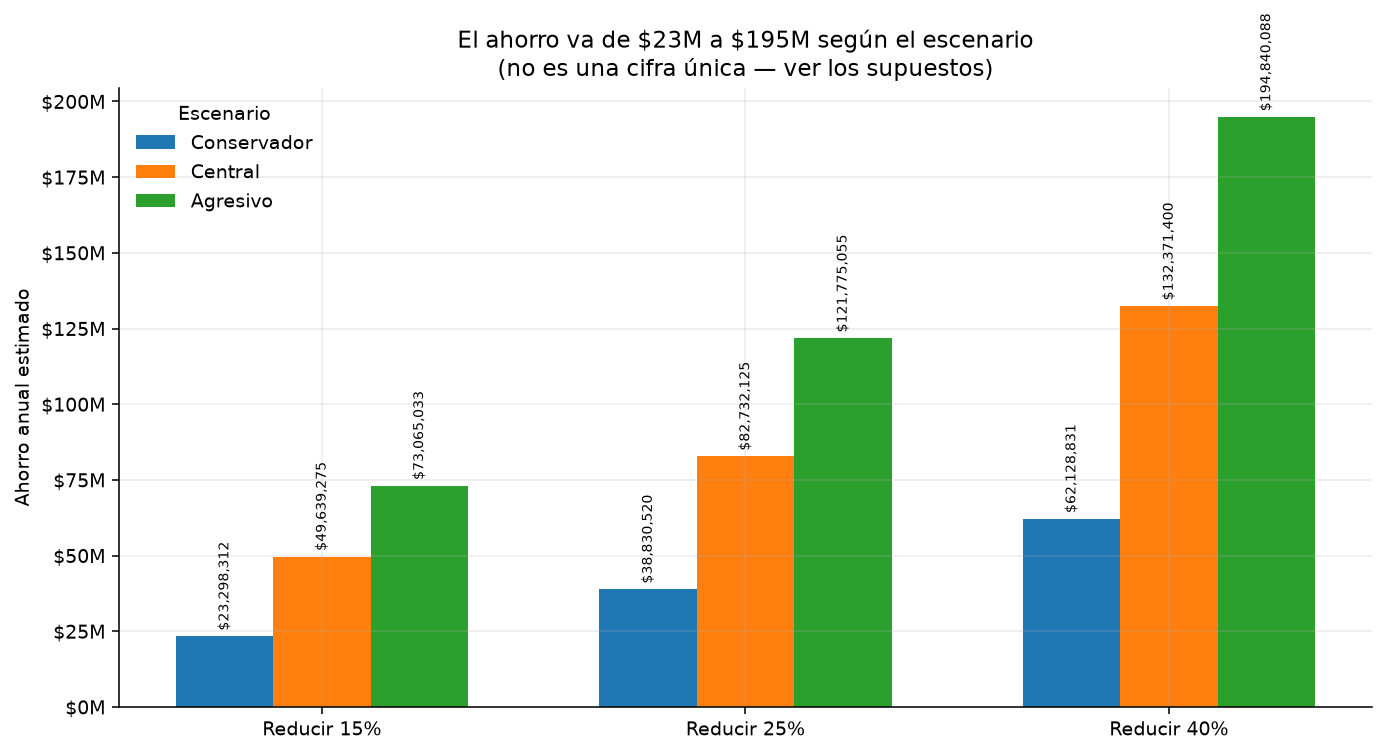

In [31]:
ejecutar_etapa("18_visualizaciones_decision.py")
mostrar_graficos([
    "G8_rotacion_original_vs_limpia.png",
    "G9_rotacion_area_ic95.png",
    "G10_distribucion_horas_extra_area.png",
    "G11_incidentes_por_turno.png",
    "G12_capacitacion_seguridad_vs_incidentes.png",
    "G13_riesgo_sucesion_por_puesto.png",
    "G14_business_case_escenarios.png",
])


**Diseño de evaluación para la auditoría nocturna.** La métrica de A.7 (línea de base vs objetivo a 12 meses) es un antes-después sin grupo de control — con 45 eventos totales, una baja futura puede ser la auditoría o puede ser azar. La exposición nocturna se concentra en tres áreas (Estampado 51, Ensamble 40, Pintura 24 personas): implementar los correctivos de a una por vez, no las tres juntas, para que las que todavía no cambiaron sirvan de control temporal. No pide dato nuevo, solo orden de implementación.

## Cierre

Se ejecutaron las 17 etapas vigentes. Las versiones mejoradas reemplazan a las versiones anteriores de limpieza y business case.


In [32]:
ETAPAS_EJECUTADAS = [
    "01_perfilado.py", "02_calidad.py", "13_limpieza_v2.py", "04_p1_p2.py",
    "05_verif_critica.py", "06_p3_p4_p5.py", "07_verif_incidentes_p5.py",
    "08_visualizaciones.py", "10_sensibilidad_he.py", "11_verif_cronicos_seguridad.py", "19_hora_extra_estructural.py", "20_costo_pieza_buena.py",
    "12_diagnostico_gaps.py", "14_eda_sistematico.py", "15_diagnostico_fragilidad.py",
    "16_rotacion_temporal.py", "17_business_case_v2.py",
    "18_visualizaciones_decision.py",
]

print(f"Etapas disponibles: {len(ETAPAS_EJECUTADAS)}")
print("Limpieza vigente: 13_limpieza_v2.py")
print("Business case vigente: 17_business_case_v2.py")


Etapas disponibles: 16
Limpieza vigente: 13_limpieza_v2.py
Business case vigente: 17_business_case_v2.py
